In [26]:
#Data loading + imports

import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


if os.path.exists("data/q2_customers.csv"):
  df = pd.read_csv("data/q2_customers.csv")
else:
  df = pd.read_csv("q2_customers.csv")

print("Data loaded sucessfully")
df.head()

Data loaded sucessfully


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [27]:
# TASK 1 -Data Preparation

#Scailing data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

#Convert back to dataframe
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

print("Scaling done")

Scaling done


The dataset is loaded sucessfully. Scaling is needed because K-Means uses distance. Without scaling, larger values can dominate the result. Scaling helps bring all the features to a similar level so that clustering is more balanced.

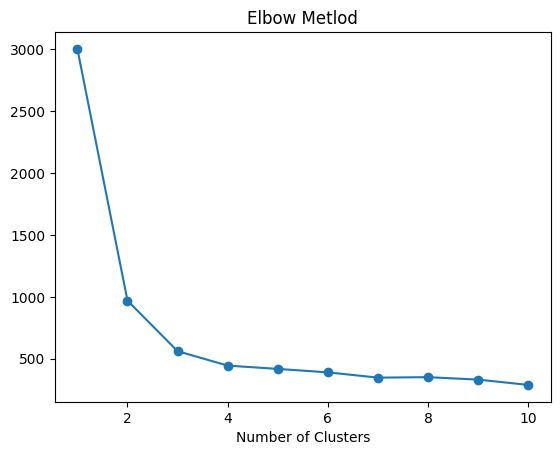

In [28]:
#TASK 2 -Chossing K (Elbow Method)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

#Calculating WCSS(Within-Cluster Sum of Squares)
for k in range(1, 11):
  model = KMeans(n_clusters=k, random_state=42)
  model.fit(scaled_df)
  wcss.append(model.inertia_)

#Plotting
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.title("Elbow Metlod")
plt.show()

As the number pf clusters increase. WCSS decrease. However, after a certain point that decrease becomes smaller. The bend in the curve appears around K = 3, so this value is selected as the optimal numbers of clusters.

In [29]:
#TASK 3 -K-Means Clustering

from sklearn.cluster import KMeans

#Create model
kmeans = KMeans(n_clusters=3, random_state=42)

#Fit and predict
df["cluster"] = kmeans.fit_predict(scaled_df)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [30]:
#Centroids

#Centroids as dataframe
centroids =pd.DataFrame(kmeans.cluster_centers_)
centroids.columns = [
    "age",
    "annual_spend",
    "visits_per_month",
    "basket_size",
    "days_since_last_visit",
    "num_categories_purchased"
]
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


Cluster 0: Customers with lower spending and fewer purchases. They visit moderately but do not spend much.

Cluster 1: High value customers. They spend more , visit frequently, and purchase more categories.

Cluster 2: Average customers. Their spending and vists are balanced and close to overall average.

In [31]:
# TASK 4 -Dimensionality Reduction with PCA

from sklearn.decomposition import PCA

# Reducing to 2 components
pca = PCA(n_components=2)
pca_data =pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])

pca_df.head()

,PC1,PC2
0,-0.333082,0.109379
1,-2.255362,0.048458
2,-0.092905,-0.679257
3,-2.017598,-0.308845
4,-2.917762,0.529368


In [32]:
# Explained variance

pca.explained_variance_ratio_

array([0.83560354, 0.05568764])

In [33]:
#Feature loading

loadings = pd.DataFrame(
  pca.components_,
  columns=[
        "age",
        "annual_spend",
        "visits_per_month",
        "basket_size",
        "days_since_last_visit",
        "num_categories_purchased"
  ],
    index=["PC1", "PC2"]
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 mainlt represents overall spending and purchase behaviour since features like annual soend and basket size have higher values.

PC2 shows variation in visit frequency and recency, indicating how often customers visit and how recently they have interacted.

These components help reduce the data while still keeping the important patterns.

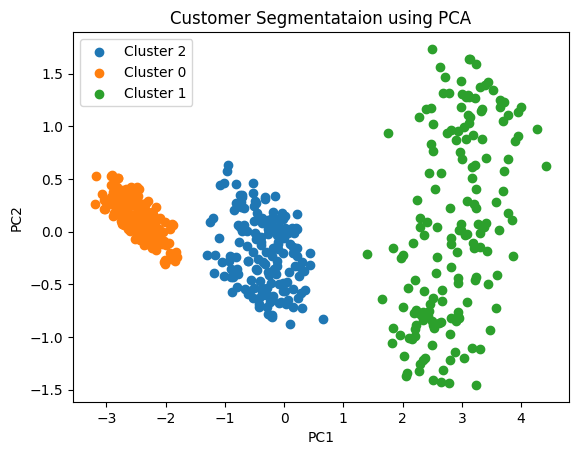

In [34]:
# TASK 5 -Cluster Visualisation

#Add cluster to PCA data
pca_df["cluster"] = df["cluster"]

#Scatter plot
plt.figure()

for c in pca_df["cluster"].unique():
  temp = pca_df[pca_df["cluster"] == c]
  plt.scatter(temp["PC1"], temp["PC2"], label=f"Cluster {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentataion using PCA")
plt.legend()
plt.show()